In [1]:
import tensorflow as tf

print(tf.__version__)

2.20.0


In [2]:
import tensorflow as tf
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [6]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [7]:
import zipfile

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [8]:
import pandas as pd

df = pd.read_csv(
    "dataset/data/train_solution_bounding_boxes (1).csv"
)

df.head()

,image,xmin,ymin,xmax,ymax
0,vid_4_1000.jpg,281.259045,187.035071,327.727931,223.225547
1,vid_4_10000.jpg,15.163531,187.035071,120.329957,236.430180
2,vid_4_10040.jpg,239.192475,176.764801,361.968162,236.430180
3,vid_4_10020.jpg,496.483358,172.363256,630.020260,231.539575
4,vid_4_10060.jpg,16.630970,186.546010,132.558611,238.386422


In [9]:
print("Dataset Shape:", df.shape)
print(df.columns.tolist())

Dataset Shape: (559, 5)
['image', 'xmin', 'ymin', 'xmax', 'ymax']


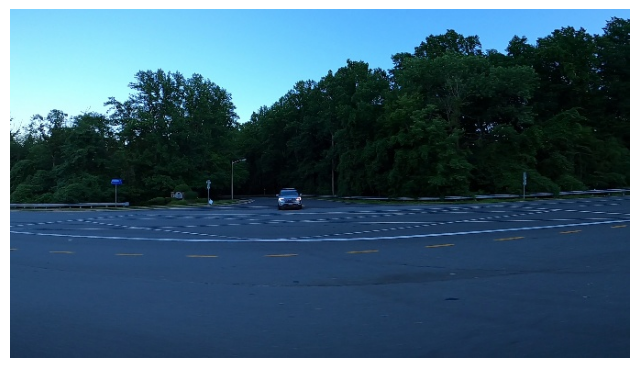

In [10]:
import os
import cv2
import matplotlib.pyplot as plt

image_name = df.iloc[0]["image"]

image_path = os.path.join(
    "dataset/data/training_images",
    image_name
)

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()

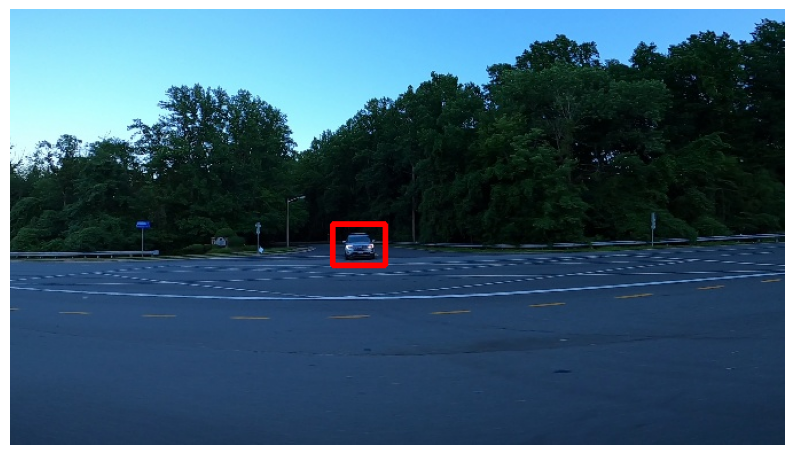

In [11]:
image_name = df.iloc[0]["image"]

image_path = os.path.join(
    "dataset/data/training_images",
    image_name
)

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

boxes = df[df["image"] == image_name]

for _, row in boxes.iterrows():

    xmin = int(row["xmin"])
    ymin = int(row["ymin"])
    xmax = int(row["xmax"])
    ymax = int(row["ymax"])

    cv2.rectangle(
        img,
        (xmin, ymin),
        (xmax, ymax),
        (255, 0, 0),
        3
    )

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis("off")
plt.show()

In [12]:
def load_image(image_name):

    image_path = os.path.join(
        "dataset/data/training_images",
        image_name
    )

    img = cv2.imread(image_path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    img = cv2.resize(
        img,
        (224,224)
    )

    img = img / 255.0

    return img

In [13]:
X = []
Y = []

for i in range(200):

    image_name = df.iloc[i]["image"]

    img = load_image(image_name)

    bbox = [
        df.iloc[i]["xmin"],
        df.iloc[i]["ymin"],
        df.iloc[i]["xmax"],
        df.iloc[i]["ymax"]
    ]

    X.append(img)
    Y.append(bbox)

X = np.array(X)
Y = np.array(Y)

print(X.shape)
print(Y.shape)

(200, 224, 224, 3)
(200, 4)


In [14]:
import tensorflow as tf

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),
    tf.keras.layers.Dense(4)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [17]:
history = model.fit(
    X,
    Y,
    epochs=10,
    batch_size=8,
    validation_split=0.2
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 471ms/step - loss: 83888.1953 - mae: 243.1258 - val_loss: 79150.9219 - val_mae: 229.8007
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 414ms/step - loss: 56450.2422 - mae: 187.1855 - val_loss: 47535.6992 - val_mae: 162.7733
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 489ms/step - loss: 31639.2148 - mae: 124.1015 - val_loss: 28242.3848 - val_mae: 114.6386
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 409ms/step - loss: 22056.0645 - mae: 102.2501 - val_loss: 23920.1055 - val_mae: 109.4634
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 334ms/step - loss: 21020.7812 - mae: 100.5269 - val_loss: 23288.0684 - val_mae: 105.7211
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 362ms/step - loss: 20674.5469 - mae: 99.4240 - val_loss: 23292.4160 - val_mae: 105.6198
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 417ms/step - loss: 20560.4180 - mae: 98.7112 - val_loss: 23413.4355 - val_mae: 105.9269
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 407ms/step - loss: 20445.0527 - mae: 98.6013 - v

In [18]:
loss, mae = model.evaluate(X, Y)

print("Loss:", loss)
print("MAE:", mae)

7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - loss: 20507.5488 - mae: 98.5823
Loss: 20507.548828125
MAE: 98.58232116699219


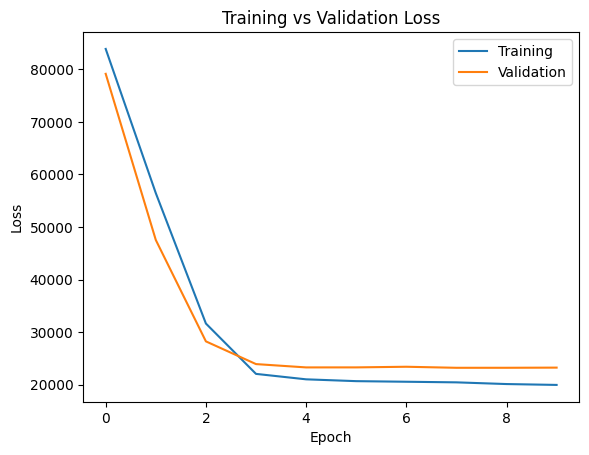

In [19]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training",
    "Validation"
])

plt.show()

In [20]:
prediction = model.predict(
    np.expand_dims(X[0], axis=0)
)

print("Predicted Bounding Box:")
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Bounding Box:
[[233.44588 166.06032 321.18173 208.3949 ]]


In [21]:
print("""
OBJECT DETECTION USING TENSORFLOW

Completed Steps:
1. Visualization Utilities
2. Data Loading
3. Data Preprocessing
4. Define Network
5. Train Model
6. Evaluate Model
7. Prediction
""")


OBJECT DETECTION USING TENSORFLOW

Completed Steps:
1. Visualization Utilities
2. Data Loading
3. Data Preprocessing
4. Define Network
5. Train Model
6. Evaluate Model
7. Prediction



In [22]:
model.save("vehicle_detection_model.keras")

print("Model Saved Successfully")

Model Saved Successfully


In [23]:
loaded_model = tf.keras.models.load_model(
    "vehicle_detection_model.keras"
)

print("Model Loaded Successfully")

Model Loaded Successfully


In [24]:
test_image = load_image(
    df.iloc[50]["image"]
)

prediction = loaded_model.predict(
    np.expand_dims(test_image, axis=0)
)

print("Predicted Bounding Box:")
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Bounding Box:
[[333.4303  216.02193 456.24854 274.48175]]


In [25]:
print("""
Project Name:
Vehicle Detection using TensorFlow

Dataset:
Vehicle Detection Dataset

Objectives:
- Load Vehicle Dataset
- Visualize Bounding Boxes
- Preprocess Images
- Train Deep Learning Model
- Predict Vehicle Bounding Boxes

Tools Used:
- TensorFlow
- OpenCV
- NumPy
- Pandas
- Matplotlib
""")


Project Name:
Vehicle Detection using TensorFlow

Dataset:
Vehicle Detection Dataset

Objectives:
- Load Vehicle Dataset
- Visualize Bounding Boxes
- Preprocess Images
- Train Deep Learning Model
- Predict Vehicle Bounding Boxes

Tools Used:
- TensorFlow
- OpenCV
- NumPy
- Pandas
- Matplotlib

